weight W is: [[3.77575758]] biais B is -5.666666662154595


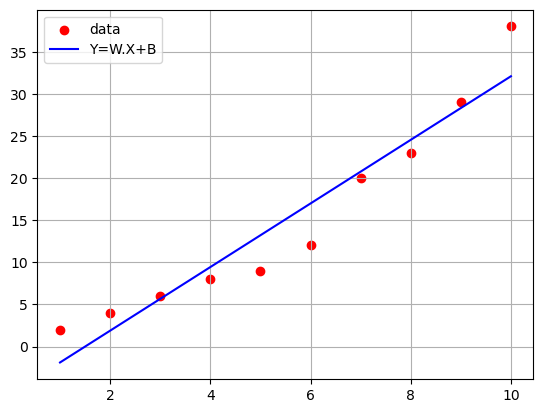

In [11]:
import numpy as np 
import matplotlib.pyplot as plt

X=np.array([1 ,2 ,3 ,4 ,5,6,7 ,8,9,10])
Y=np.array([2 ,4 ,6 ,8,9,12 ,20, 23 ,29 ,38])
#reshape X et Y
X=X.reshape(-1 ,1)
Y=Y.reshape(-1 ,1)

W=np.array([0.1])
W=W.reshape(-1 ,1)
B=0
lr=0.01
n=len(X)

for i in range(10000): 
    Y_pred=X @ W +B
    error=Y-Y_pred
    dw=-(1/n)*np.sum(X.T @ error)
    db=-(1/n)*np.sum(error)

    W=W-lr*dw
    B=B-lr*db

print("weight W is:" ,W ,'biais B is',B)

plt.scatter(X ,Y ,color='red' ,label='data') 
plt.plot(X ,Y_pred ,c='blue' ,label='Y=W.X+B')
plt.legend()
plt.grid()
plt.show()

# Regression Polynomiale : $ Y=w_1 \cdot x+ w_2 \cdot x^2 +b $ 
### $$ Y=\begin{pmatrix} x \\ x^2 \end{pmatrix} \cdot \begin{pmatrix} w_1 & w_2 \end{pmatrix} +B$$ 
### $$ Y=X^T \cdot W+ B $$

(4, 1) (4, 1) (2, 1) (4, 2)
W  : [[-2.05242593]
 [ 1.38172018]] B : 2.73356781476693


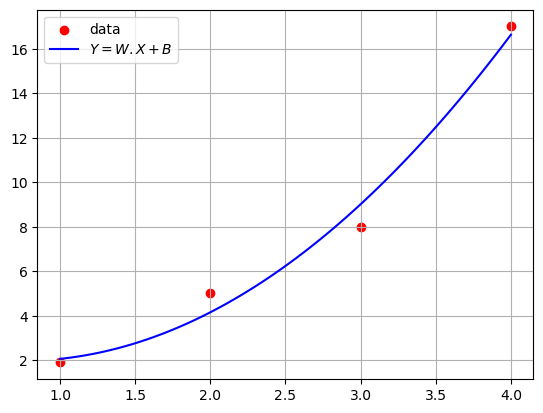

In [51]:
import numpy as np 
import matplotlib.pyplot as plt

X=np.array([1 ,2 ,3,4 ])
Y=np.array([1.9 ,5 ,8 ,17 ])

X=X.reshape(-1 ,1)
Y=Y.reshape(-1 ,1)
X_poly=np.column_stack((X ,X**2)) 

W=np.array([0.1 ,0.1])
W=W.reshape(-1 ,1)
B=0
lr=0.01
n=len(X)
print(X.shape ,Y.shape ,W.shape ,X_poly.shape)

for i in range(10000): 

    Y_pred=X_poly @ W+B
    error=Y-Y_pred

    dw=-(1/n)*(X_poly.T @ error)
    db=-(1/n)*np.sum(error)

    W=W-lr*dw
    B=B-lr*db

#donnes de la courbesabs
X_courbes=np.linspace(1 ,4,100).reshape(-1 ,1)
X_courbes_poly=np.column_stack((X_courbes ,X_courbes**2))
#X_courbes=X_courbes.reshape(-1 ,1)

Y_pred_courbes=X_courbes_poly @ W +B

print("W  :",W,"B :" ,B)
plt.scatter(X ,Y ,c='red' ,label='data')
plt.plot(X_courbes ,Y_pred_courbes ,c='blue' ,label='$Y=W.X+B$')
plt.legend()
plt.grid()
plt.show()

# Introduction to DeepLearning
## perceptron multicouche : XOR
### Nous utiliserons la fonctiom signoide pour activer notre neurone:
### $$ \sigma(x)=\frac{1}{1+e^{-x}} $$
## dimensions des matrices
### X est (4 ,2) ; $ W_h $ est (2 ,2 ) et $ W_o $ est (2 ,1) 
### $B_h$ est (1 ,2) et $B_0$ est (1 ,1)

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 

X=np.array([[0 ,0] ,[0 ,1] ,[1 ,0] ,[1,1]])
Y=np.array([0 ,1 ,1 ,0])
Y=Y.reshape(-1 ,1)
# initialisations de poids
h_nodes = 4 
np.random.seed(10) # Nouvelle graine pour tester un autre départ

# Initialisation plus stable
W_h = np.random.randn(2, h_nodes) * np.sqrt(1/2)
W_o = np.random.randn(h_nodes, 1) * np.sqrt(1/h_nodes)
B_h = np.zeros((1, h_nodes))
B_o = np.zeros((1, 1))
n=len(X)
lr=0.5
# fonction d'activation
def signoide(a): 
    sigma_X=1/(1+np.exp(-a))
    return sigma_X
# derivee de la fonction d'activation
def signoide_derivate(b) : 
    sigma_derivate_X=signoide(b)*(1-signoide(b))
    return sigma_derivate_X


for i in range(50000) : 
    Z_h=X @ W_h + B_h
    # activation on layers hiddensA
    A_h=signoide(Z_h)

    #output layers 
    Z_o=A_h @ W_o + B_o
    #activation in layers oupiut
    Y_pred=signoide(Z_o)

    # calculs des gradients 

    error=Y_pred-Y
    S_o=(error * signoide_derivate(Z_o)) # taille (4 ,1)
    S_h=(S_o @ W_o.T) *signoide_derivate(Z_h) # taille (4 ,2)

    #gradients 

    dW_o=(1/n)*(A_h.T @ S_o )#taille (2,1)
    #dW_h=S_h.T @ X      #taille(2,2)
    dW_h = (1/n)*(X.T @ S_h)

    dB_h=(1/n)*np.sum(S_h ,axis=0, keepdims=True)
    dB_o=(1/n)*np.sum(S_o ,axis=0, keepdims=True)

    W_h=W_h-lr*dW_h
    W_o=W_o-lr*dW_o
    B_h=B_h-lr*dB_h
    B_o=B_o-lr*dB_o

print(Y_pred)

[[0.01317099]
 [0.98798276]
 [0.98847913]
 [0.01328039]]


# XOR avec graphique de frontière de decision apprise par l'IA

[[0.01317099]
 [0.98798276]
 [0.98847913]
 [0.01328039]]


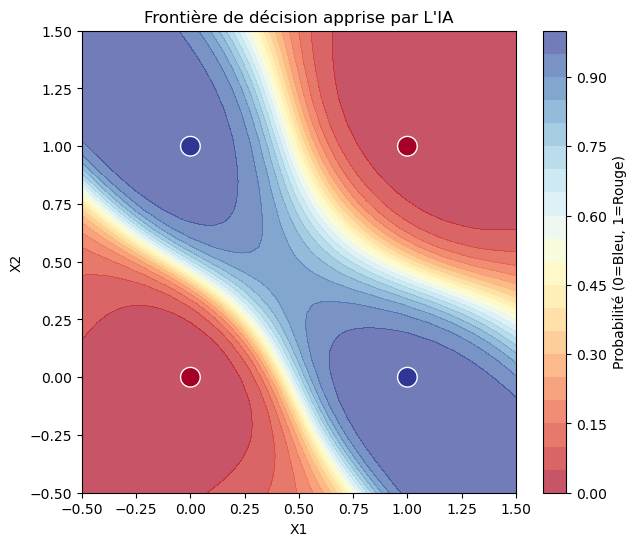

In [2]:
import numpy as np 
import matplotlib.pyplot as plt 

X=np.array([[0 ,0] ,[0 ,1] ,[1 ,0] ,[1,1]])
Y=np.array([0 ,1 ,1 ,0])
Y=Y.reshape(-1 ,1)
# initialisations de poids
h_nodes = 4 
np.random.seed(10) # Nouvelle graine pour tester un autre départ

# Initialisation plus stable
W_h = np.random.randn(2, h_nodes) * np.sqrt(1/2)
W_o = np.random.randn(h_nodes, 1) * np.sqrt(1/h_nodes)
B_h = np.zeros((1, h_nodes))
B_o = np.zeros((1, 1))
n=len(X)
lr=0.5
# fonction d'activation
def signoide(a): 
    sigma_X=1/(1+np.exp(-a))
    return sigma_X
# derivee de la fonction d'activation
def signoide_derivate(b) : 
    sigma_derivate_X=signoide(b)*(1-signoide(b))
    return sigma_derivate_X


for i in range(50000) : 
    Z_h=X @ W_h + B_h
    # activation on layers hiddensA
    A_h=signoide(Z_h)

    #output layers 
    Z_o=A_h @ W_o + B_o
    #activation in layers oupiut
    Y_pred=signoide(Z_o)

    # calculs des gradients 

    error=Y_pred-Y
    S_o=(error * signoide_derivate(Z_o)) # taille (4 ,1)
    S_h=(S_o @ W_o.T) *signoide_derivate(Z_h) # taille (4 ,2)

    #gradients 

    dW_o=(1/n)*(A_h.T @ S_o )#taille (2,1)
    #dW_h=S_h.T @ X      #taille(2,2)
    dW_h = (1/n)*(X.T @ S_h)

    dB_h=(1/n)*np.sum(S_h ,axis=0, keepdims=True)
    dB_o=(1/n)*np.sum(S_o ,axis=0, keepdims=True)

    W_h=W_h-lr*dW_h
    W_o=W_o-lr*dW_o
    B_h=B_h-lr*dB_h
    B_o=B_o-lr*dB_o

print(Y_pred)

# 1. Création d'une figure avec deux graphiques
# 1. Créer une grille de points (plusieurs petits points partout)
x_range = np.linspace(-0.5, 1.5, 50)
y_range = np.linspace(-0.5, 1.5, 50)
xx, yy = np.meshgrid(x_range, y_range)

# 2. Faire passer toute la grille dans ton réseau (Forward)
grid = np.c_[xx.ravel(), yy.ravel()]
# On utilise tes poids entraînés W_h, B_h, W_o, B_o
Z_h_grid = grid @ W_h + B_h
A_h_grid = signoide(Z_h_grid)
Z_o_grid = A_h_grid @ W_o + B_o
predictions = signoide(Z_o_grid).reshape(xx.shape)

# 3. Dessiner la frontière
plt.figure(figsize=(7, 6))
# Dessine les zones de couleurs (la frontière)
plt.contourf(xx, yy, predictions, levels=20, cmap='RdYlBu', alpha=0.7)
plt.colorbar(label='Probabilité (0=Bleu, 1=Rouge)')

# Dessine tes 4 points de départ pour comparer
plt.scatter(X[:,0], X[:,1], c=Y.flatten(), cmap='RdYlBu', edgecolors='white', s=200)

plt.title("Frontière de décision apprise par L'IA")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()